# Predicting House Price using Neural Network Regression 

### Boston Housing Dataset

This is an attempt to predict the median price of homes in a given Boston suburb in the mid-1970s, given data points about the suburb at the time, such as the crime rate, the local property tax rate, and so on. It has relatively few data points: only 506, split between 404 training samples and 102 test samples. And each feature in the input data (for example, the crime rate) has a different scale. For instance, some values are proportions, which take values between 0 and 1, others take values between 1
and 12, others between 0 and 100, and so on.

#### 1. Load the Boston housing dataset

In [21]:
import pandas as pd
from keras.datasets import boston_housing
from sklearn.datasets import load_boston
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

#### 2. Explore the dataset

In [18]:
boston = load_boston()

# Load dataset into dataframe but change column names to more meaningful business names
df = pd.DataFrame(boston['data'], columns=['Crime Rate', 'Residential Land Zones', 'Non-retail Business Acres',
                                          'Charles River tract bounds', 'N.O. Concentration', '# of Rooms', 'Age',
                                          'Distance to Employment', 'Highway Accessibility', 'Property Tax Rate',
                                          'Pupil Teacher Ratio', 'B', '% Lower Income'])

# drop the "B" variable as it adds racial bias which has no place in our models
df.drop("B", axis=1, inplace=True)


In [19]:
df 

,Crime Rate,Residential Land Zones,Non-retail Business Acres,Charles River tract bounds,N.O. Concentration,# of Rooms,Age,Distance to Employment,Highway Accessibility,Property Tax Rate,Pupil Teacher Ratio,% Lower Income
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,6.48


<AxesSubplot: >

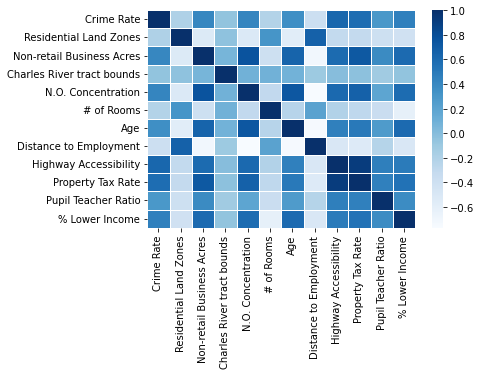

In [24]:
sns.heatmap(df.corr(), linewidths=1, linecolor='white', cmap='Blues')

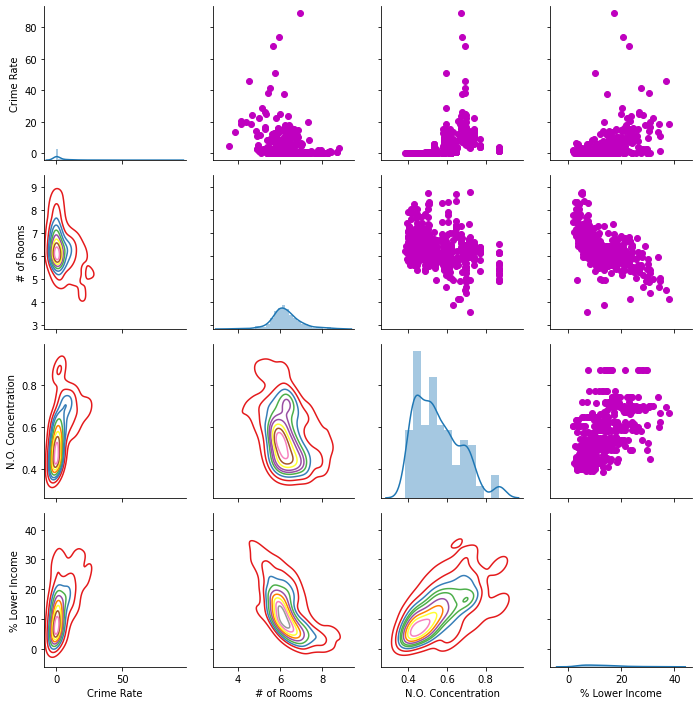

In [28]:
import matplotlib.pyplot as plt
g = sns.PairGrid(df[['Crime Rate', '# of Rooms', 'N.O. Concentration', '% Lower Income']])
g.map_upper(plt.scatter, color="m")
g.map_lower(sns.kdeplot, cmap="Set1")
g.map_diag(sns.distplot)

### 3. Prepare the data

In [32]:
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

In [33]:
print("The shape of train data is: ", train_data.shape)
print("The shape of the testing data is: ", test_data.shape)

The shape of train data is:  (404, 13)
The shape of the testing data is:  (102, 13)


In [34]:
## Normalizing the data 
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std
test_data -= mean
test_data /= std

### 4. Build the model

In [35]:
# Building our network

from keras import models
from keras import layers
def build_model():
    model = models.Sequential()
    model.add(layers.Dense(64, activation='relu', input_shape=(train_data.shape[1],)))
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(1))
    model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
    return model

### 5. Validate the approach using K-fold validation

In [36]:
import numpy as np
k=4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []

In [37]:
for i in range(k):
    print('processing fold #', i)
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate([train_data[:i * num_val_samples],
    train_data[(i + 1) * num_val_samples:]],axis=0)
    partial_train_targets = np.concatenate([train_targets[:i * num_val_samples],
    train_targets[(i + 1) * num_val_samples:]],axis=0)
    model = build_model()
    model.fit(partial_train_data, partial_train_targets,epochs=num_epochs, batch_size=1, verbose=0)
    val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
    all_scores.append(val_mae)

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


In [38]:
print(all_scores)
print(np.mean(all_scores))

[2.3375468254089355, 2.72135066986084, 2.5340845584869385, 2.2680060863494873]
2.4652470350265503


### 6. Save the validation logs at each fold

In [39]:
num_epochs = 500
all_mae_histories = []
for i in range(k):
    print('processing fold #', i)
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
    partial_train_data = np.concatenate([train_data[:i * num_val_samples],
    train_data[(i + 1) * num_val_samples:]],axis=0)
    partial_train_targets = np.concatenate([train_targets[:i * num_val_samples],
    train_targets[(i + 1) * num_val_samples:]],axis=0)
    model = build_model()
    history = model.fit(partial_train_data, partial_train_targets, 
    validation_data=(val_data, val_targets), epochs=num_epochs, batch_size=1, verbose=0)
    #print(history.keys())
    mae_history = history.history['mae']
    all_mae_histories.append(mae_history)

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


### 7. Build the history of successive mean K-fold validation scores

In [41]:
average_mae_history = [np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)]

### 8. Plot the validation scores

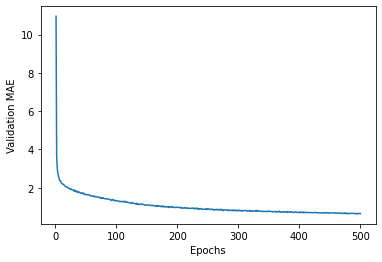

In [42]:
import matplotlib.pyplot as plt
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.show()

### 9. Plotting validation scores, excluding the first 10 data points

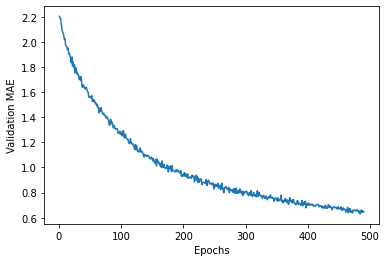

In [43]:
truncated_mae_history = average_mae_history[10:]
plt.plot(range(1, len(truncated_mae_history) + 1), truncated_mae_history)
plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.show()

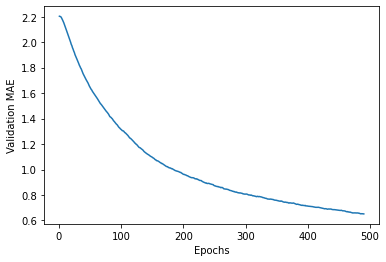

In [44]:
def smooth_curve(points, factor=0.9):
    smoothed_points = []
    for point in points:
        if smoothed_points:
            previous = smoothed_points[-1]
            smoothed_points.append(previous * factor + point * (1 - factor))
        else:
            smoothed_points.append(point)
    return smoothed_points

smooth_mae_history = smooth_curve(average_mae_history[10:])

plt.plot(range(1, len(smooth_mae_history) + 1), smooth_mae_history)
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.show()

### 10. Change parameters of the model

In [45]:
## Changing parameters and number of epoch of the model
model = build_model()
model.fit(train_data, train_targets,
epochs=80, batch_size=16, verbose=0)
test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)

4/4 [==============================] - 0s 4ms/step - loss: 18.0067 - mae: 2.7048


### 11. Performance

In [46]:
## Performance of the new model

test_mae_score

2.7047626972198486

### 12. Generating Predictions
When calling predict() on our binary classification model, we retrieved a scalar score between 0 and 1 for each input sample. With our multiclass classification model, we retrieved a probability distribution over all classes for each sample. Now, with this scalar regression model, predict() returns the model’s guess for the sample’s price in thousands of dollars:

In [47]:
predictions = model.predict(test_data)
predictions[0]


4/4 [==============================] - 0s 4ms/step


array([9.320575], dtype=float32)

*The first house in the test set is predicted to have a price of about $10,000.*